**Práctica 1**

Notebook centrado en cómo implementar y probar heurísticas nuevas, así como en la comparación de heurísticas. 

Es el cuaderno principal para desarrollar y validar las nuevas funciones heurísticas solicitadas en la práctica.

En principio si usas Polilabs no necesitas instalar nada, si lo usas en otro ordenador es posible que tengas que instalar alguno de estos paquetes:

**pip install matplotlib tabulate numpy**

In [ ]:
pip install matplotlib tabulate numpy

In [14]:
import search
from search import *

**Método que implementa una nueva heurística**

En este caso la nueva heurística es simplemente multiplicar por 2 la distancia de Manhatann

In [15]:
# Nueva heurística a probar: 2 * distancia de Manhattan
def nueva_heuristica(state, end_state):
    """
    Heurística que multiplica por 2 la distancia Manhattan 
    """
    return 2 * getManhattanDistance(state, end_state) 

# Una sola línea basta para que run_algorithm y run_all_algorithms la conozcan.
register_heuristic("Nueva Heurística", nueva_heuristica)


In [ ]:
# Implementamos de nuevo Manhattan Distance
def get_Manhattan2(state, end_state):
    size = math.sqrt(len(state)) # Obtenemos tamaño puzle

    # Variable para acumular coste total
    total = 0
    # Por cada ficha
    for i in range (1, len(state)):

        # Pos 2D en estado actual
        posAct = state.index(i) 
        
        filaAct = posAct // size
        colAct = posAct % size
        
        # Pos 2D en estado final
        posFin = end_state.index(i) 

        filaFin = posFin // size
        colFin = posFin % size

        # Calcula distancia Manhattan
        dist = abs(filaFin - filaAct) + abs(filaAct - filaFin)

        # Acumulo el valor
        total += dist
        
    return total

register_heuristic("Manhattan2", get_Manhattan2)

# Convertir la matriz en una lista unidimensional
initial_state = [num for row in initial_state_matrix for num in row]
# Convertir la matriz en una lista unidimensional
end_state = [num for row in end_state_matrix for num in row]

print("Nueva heurística:", nueva_heuristica(initial_state, end_state))
print("Manhattan 2:", get_Manhattan2(initial_state, end_state))


Nueva heurística: 32
Manhattan 2: 16.0


In [24]:
def get_piezas_descolocadas(state, end_state): 
    """
    Compara todas las piezas y suma 1 por cada pieza descolocada
    """

    total = 0 # 

    size = math.sqrt(len(state)) # Obtenemos tamaño puzle

    descolocadas = 0 # Variable global para saber el nº de fichas descolocadas
    for i in range (1, len(state)):
        
        posAct = state.index(i)
        posEnd = end_state.index(i)
        
        colocada = abs(posAct - posEnd)

        if (colocada != 0): # por las propiedaddes del puzzle (mat. y col.)
            descolocadas += 1
        
    return descolocadas 

register_heuristic("A (Piezas descolocadas)", get_piezas_descolocadas)

# Convertir la matriz en una lista unidimensional
initial_state = [num for row in initial_state_matrix for num in row]
# Convertir la matriz en una lista unidimensional
end_state = [num for row in end_state_matrix for num in row]

print("A (Piezas descolocadas):", get_piezas_descolocadas(initial_state, end_state))

A (Piezas descolocadas): 7


**Ejemplo con tamaño 3**

Se define el estado inicial y el final, se ejecutan todos los algoritmos disponibles y se visualizan los resultados

BFS executed
DFS-B executed
ID executed
Voraz (Manhattan) executed
A* (Manhattan) executed
A (MD + LC) executed
IDA* (Manhattan) executed
Nueva Heurística executed
Manhattan2 executed
Piezas descolocadas executed
A (Piezas descolocadas) executed
+-------------------------+--------+---------+-------------+-------------------+------------------+--------------------+
| Algorithm               |   Cost |   Depth |    Time (s) |   Nodes Generated |   Nodes Expanded |   Max Nodes Stored |
+=========================+========+=========+=============+===================+==================+====================+
| BFS                     |     22 |      23 | 0.58551     |            233687 |            86871 |             110729 |
+-------------------------+--------+---------+-------------+-------------------+------------------+--------------------+
| DFS-B                   |     38 |      40 | 3.09709     |           2028383 |          1301341 |                 76 |
+-------------------------+-

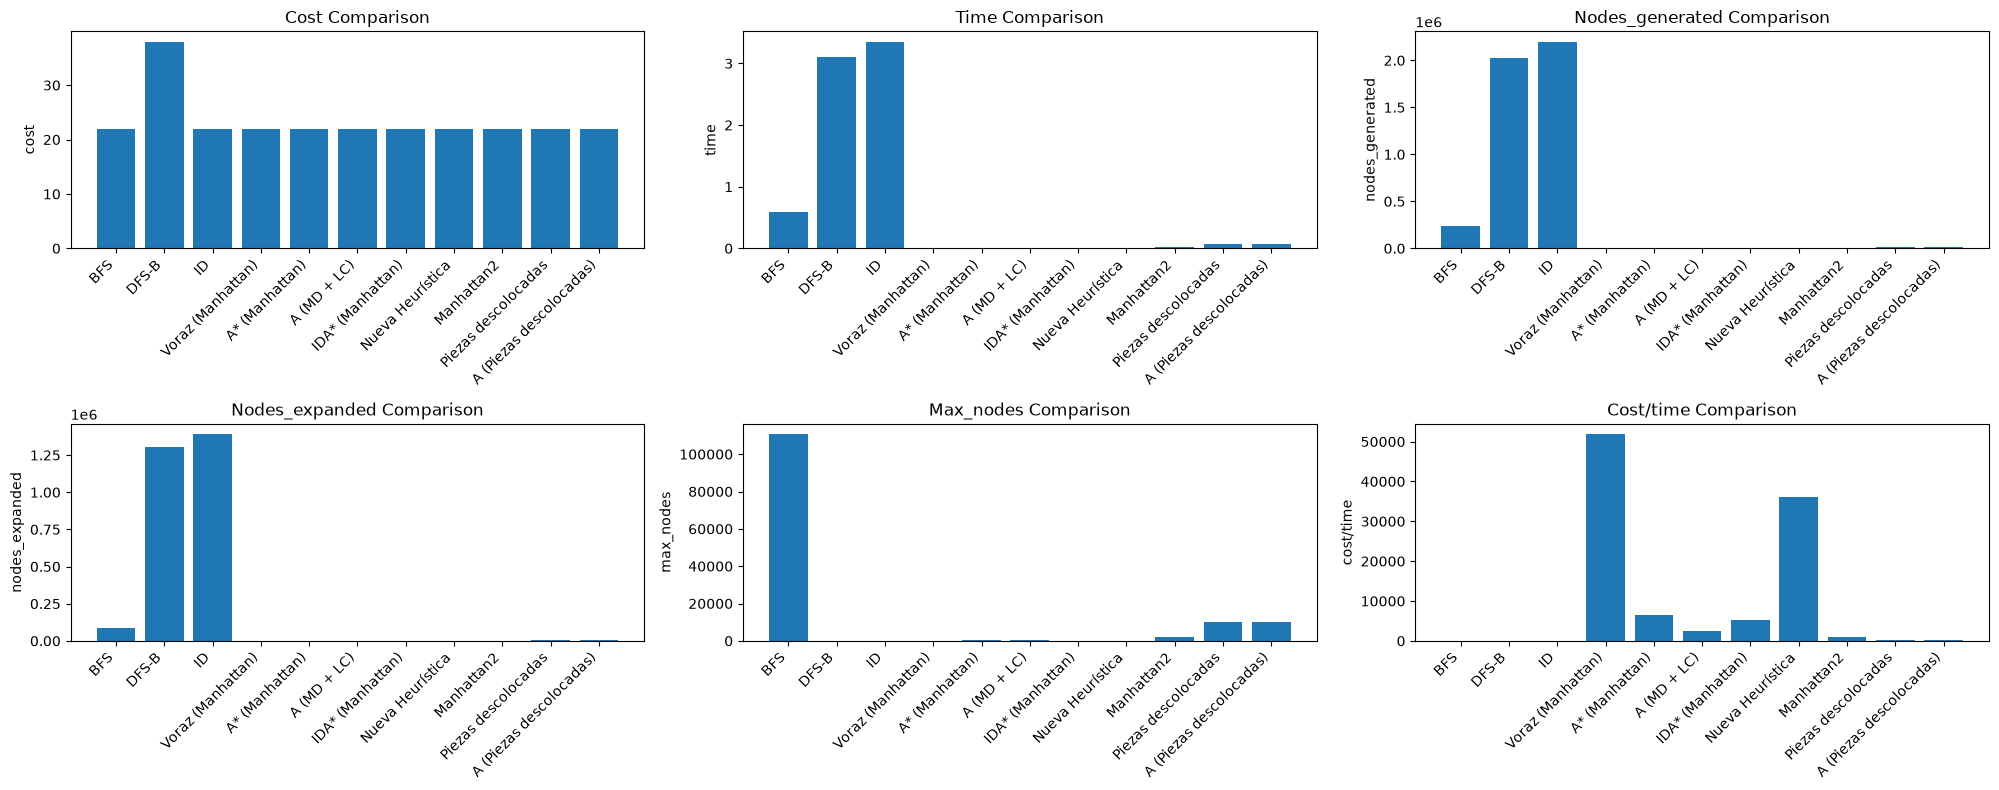

In [25]:
# Tamaño 3

size = 3  # Example for a 3x3 puzzle

initial_state_matrix = [
    [7, 8, 1],
    [4, 0, 6],
    [2, 3, 5]
]


end_state_matrix = [
    [1, 2, 3],
    [8, 0, 4],
    [7, 6, 5]
]

# Convertir la matriz en una lista unidimensional
initial_state = [num for row in initial_state_matrix for num in row]
# Convertir la matriz en una lista unidimensional
end_state = [num for row in end_state_matrix for num in row]

# Ejecutar todos los algoritmos y mostrar los resultados en una tabla
results = {}
if isSolvable(initial_state, end_state):
    # Llamar a la función para ejecutar todos los algoritmos
    results = run_all_algorithms(initial_state, end_state, size, 40)
    show_results(results)
    plot_algorithm_comparison(results)
else:
    print("The puzzle is not solvable.")




**Ejemplo de estudio de admisibilidad y consistencia**

Para el estado inicial anterior se compara el valor de la heurística con el coste óptimo obtenido mediante BFS. Después se utiliza `check_consistency` para buscar un posible contraejemplo de consistencia. Estas comprobaciones sobre un único ejemplo aportan evidencia, pero no constituyen una demostración general.

In [5]:
# Estudio de admisibilidad para el estado inicial anterior
h_initial = nueva_heuristica(initial_state, end_state)
h_goal = nueva_heuristica(end_state, end_state)
optimal_cost = results['BFS']['cost']

print("Valor en el estado inicial:", h_initial)
print("Valor en el estado objetivo:", h_goal)
print("Coste óptimo obtenido con BFS:", optimal_cost)
print("¿Es no negativa en este ejemplo?", h_initial >= 0)
print("¿Vale cero en el objetivo?", h_goal == 0)
print("¿No supera el coste óptimo?", h_initial <= optimal_cost)

# Estudio de consistencia desde el mismo estado inicial
consistency_result = check_consistency(
    nueva_heuristica, initial_state, end_state, size, max_states=10000
)
print("Resultado de la prueba de consistencia:")
print(consistency_result)


Valor en el estado inicial: 32
Valor en el estado objetivo: 0
Coste óptimo obtenido con BFS: 22
¿Es no negativa en este ejemplo? True
¿Vale cero en el objetivo? True
¿No supera el coste óptimo? False
Resultado de la prueba de consistencia:
{'consistent': False, 'complete': False, 'states_checked': 1, 'counterexample': {'state': [7, 8, 1, 4, 0, 6, 2, 3, 5], 'child': [7, 0, 1, 4, 8, 6, 2, 3, 5], 'h_state': 32, 'h_child': 30, 'step_cost': 1}}


**Pregunta**

¿Cómo se comporta la nueva heurística?  ¿Es A*?  ¿Puedes estar seguro/a?

**Respuesta:**

.


**Prueba con tamaño 4**

In [ ]:
 # Tamaño 4

size = 4
initial_state_matrix = [
    [13, 2, 10, 3],
    [1, 12, 8, 4],
    [5, 0, 9, 6],
    [15, 14, 11, 7]
]


end_state_matrix = [
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 0]
]

# Convertir la matriz en una lista unidimensional
initial_state = [num for row in initial_state_matrix for num in row]
# Convertir la matriz en una lista unidimensional
end_state = [num for row in end_state_matrix for num in row]

# Ejecutar algoritmos concretos incluyendo nueva heurística
results = {}
if isSolvable(initial_state, end_state):
    # Llamar a la función para ejecutar los algoritmos
    algo_result = run_algorithm('A* (Manhattan)', initial_state, end_state, size)
    results.update(algo_result)
    
    algo_result = run_algorithm('Voraz (Manhattan)', initial_state, end_state, size)
    results.update(algo_result)

    algo_result = run_algorithm('Nueva Heurística', initial_state, end_state, size)
    results.update(algo_result)
        
    show_results(results)
else:
    print("The puzzle is not solvable.")


**Pregunta** 

¿Y qué opinas ahora ?

**Respuesta**

.

**Ejemplo con tamaño 5**

In [ ]:
# Tamaño 5

size = 5
initial_state_matrix = [
  [1, 2, 3, 4, 5],
  [6, 7, 8, 9, 10],
  [0, 12, 13, 14, 15],
  [16, 17, 18, 19, 20],
  [21, 22, 24, 23, 11]
]

end_state_matrix = [
  [1, 2, 3, 4, 5],
  [6, 7, 8, 9, 10],
  [11, 12, 13, 14, 15],
  [16, 17, 18, 19, 20],
  [21, 22, 23, 24, 0]
]

# Convertir la matriz en una lista unidimensional
initial_state = [num for row in initial_state_matrix for num in row]
# Convertir la matriz en una lista unidimensional
end_state = [num for row in end_state_matrix for num in row]

# Ejecutar un par de algoritmos concretos
results = {}
if isSolvable(initial_state, end_state):
    # Llamar a la función para ejecutar los algoritmos
    algo_result = run_algorithm('A* (Manhattan)', initial_state, end_state, size)
    results.update(algo_result)
    
    algo_result = run_algorithm('Voraz (Manhattan)', initial_state, end_state, size)
    results.update(algo_result)

    algo_result = run_algorithm('Nueva Heurística', initial_state, end_state, size)
    results.update(algo_result)
        
    show_results(results)

else:
    print("The puzzle is not solvable.")



**Prueba con tamaño n generando automaticamente estados finales e iniciales**

Se plantea como generalizar a n el tamaño del puzzle

In [ ]:
# Prueba con tamaño n generando automaticamente estados finales e iniciales 
size = 3
end_state = generate_ordered_state(size)
#end_state = generate_spiral_state(size)
initial_state = generate_random_state(size, end_state)


print("Initial state:\n")
visualize_state(initial_state)

print("\nEnd state:\n")
visualize_state(end_state)

# Ejecutar unos algoritmos concretos
results = {}

alg_results = run_algorithm('Voraz (Manhattan)', initial_state, end_state, size)
results.update(alg_results)
alg_results = run_algorithm('A* (Manhattan)', initial_state, end_state, size)
results.update(alg_results)
alg_results = run_algorithm('A (MD + LC)', initial_state, end_state, size)
results.update(alg_results)
algo_result = run_algorithm('Nueva Heurística', initial_state, end_state, size)
results.update(algo_result)

show_results(results)
plot_algorithm_comparison(results)

#show_path_for_algorithm(results, 'A (MD + LC)', size)